In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.formula.api as smf
import statsmodels.api as sm
import plotly.express as px
import seaborn as sns
import altair as alt

In [2]:
kc = pd.read_csv('kc_house_data.csv')

In [3]:
kc.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [4]:
# Change column type to datetime64[ns] for column: 'date'
# kc = kc.astype({'date': 'datetime64[s]'})
# kc.date.str[:8].astype('datetime64[s]')[0] # same result
kc['date'] = pd.to_datetime(kc.date)

In [5]:
sqft_to_sqmeters = 0.09290303997

In [6]:
kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float})

In [7]:
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

In [8]:
kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

In [9]:
kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

In [10]:
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan

In [11]:
kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan

In [12]:
alt.data_transformers.disable_max_rows()
alt.renderers.enable('png')

RendererRegistry.enable('png')

In [13]:
np.ones(21613)

array([1., 1., 1., ..., 1., 1., 1.], shape=(21613,))

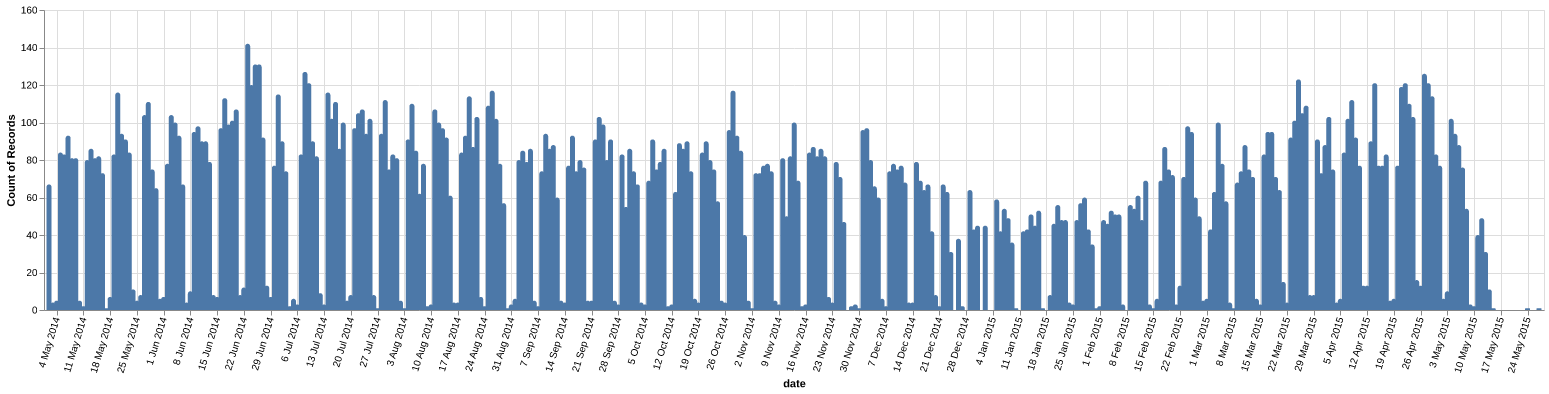

In [14]:
alt.Chart(kc, width=1500).mark_bar(
    tooltip=True,
    opacity=1,
    cornerRadiusEnd=10,
).encode(
    alt.X('date:T').axis(
        labelAngle=-73,
        format='%e %b %Y'),
    alt.Y('count()'),
)

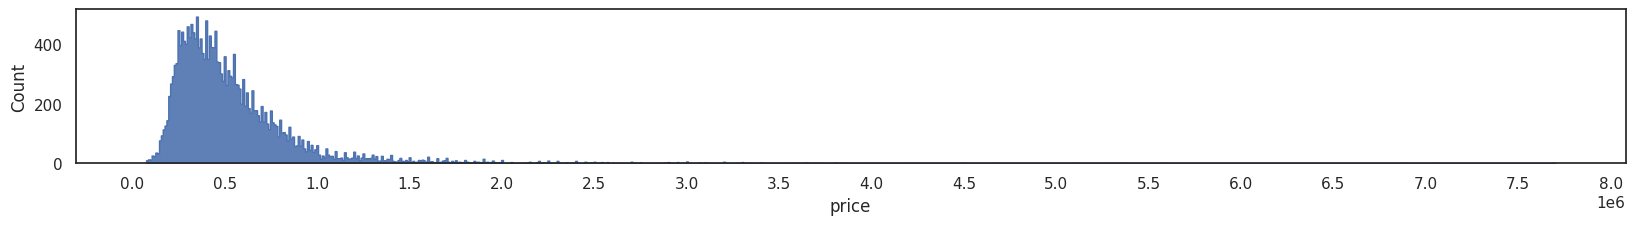

In [15]:
sns.set(rc={"figure.figsize":(20,2)})
sns.set_style('white')
sns.histplot(data=kc.price, element='step', binwidth=10**4, alpha=0.9)
plt.locator_params(nbins=27, axis='x')

In [16]:
pd.DataFrame(kc.floors.value_counts()).T

floors,1.0,2.0,1.5,3.0,2.5,3.5
count,10680,8241,1910,613,161,8


In [17]:
pd.DataFrame(kc.bedrooms.value_counts()).T

bedrooms,3,4,2,5,6,1,7,0,8,9,10,11,33
count,9824,6882,2760,1601,272,199,38,13,13,6,3,1,1


In [18]:
pd.DataFrame(kc.bathrooms.value_counts()).T.iloc[:,:15]

bathrooms,2.50,1.00,1.75,2.25,2.00,1.50,2.75,3.00,3.50,3.25,3.75,4.00,4.50,4.25,0.75
count,5380,3852,3048,2047,1930,1446,1185,753,731,589,155,136,100,79,72


In [19]:
pd.DataFrame(kc.bathrooms.value_counts()).T.iloc[:,15:]

bathrooms,4.75,5.00,5.25,0.00,5.50,1.25,6.00,0.50,5.75,6.75,8.00,6.50,6.25,7.75,7.50
count,23,21,13,10,10,9,6,4,4,2,2,2,2,1,1


In [20]:
kc[['waterfront', 'view', 'condition', 'grade']].apply(lambda x: x.value_counts()).T.fillna('')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
waterfront,21450.0,163.0,,,,,,,,,,,,
view,19489.0,332.0,963.0,510.0,319.0,,,,,,,,,
condition,,30.0,172.0,14031.0,5679.0,1701.0,,,,,,,,
grade,,1.0,,3.0,29.0,242.0,2038.0,8981.0,6068.0,2615.0,1134.0,399.0,90.0,13.0


Text(0.5, 0, 'square meters')

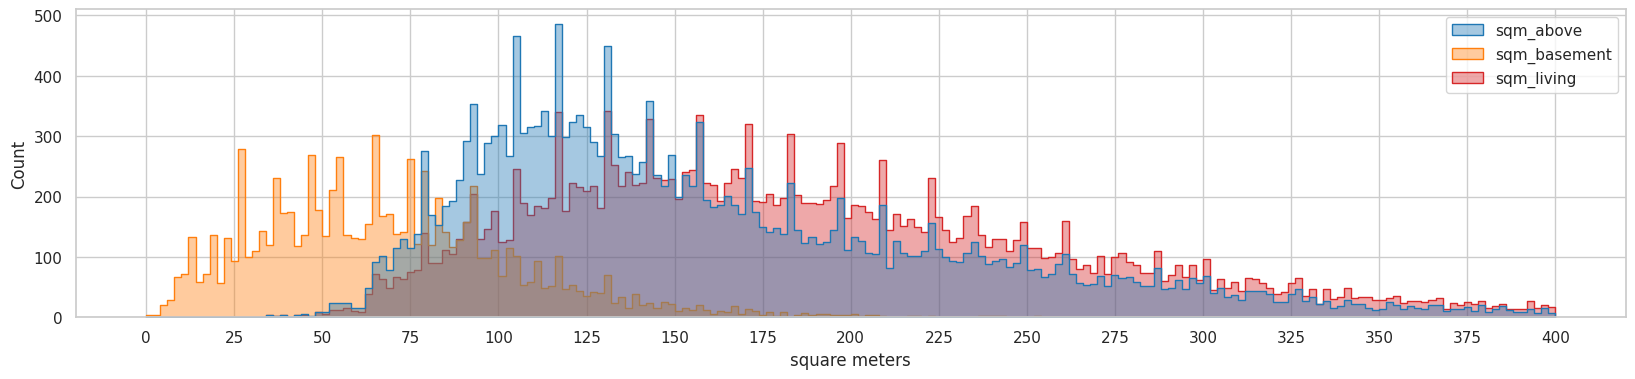

In [21]:
sns.set(rc={"figure.figsize":(20,4)})
sns.set_style('whitegrid')
sns.histplot(kc[['sqm_above', 'sqm_basement', 'sqm_living']],
             binrange=(0,400), binwidth=2, palette=['#1f77b4', '#ff7f0e', '#d62728'],
             kde=False, kde_kws={'clip':(0,400)},
             multiple='layer', element='step', alpha=0.4, linewidth=1)
plt.locator_params(axis='x', nbins=20)
plt.xlabel('square meters')

In [22]:
# px.histogram(kc, ['sqm_above', 'sqm_basement','sqm_living'],
#             color_discrete_sequence=px.colors.qualitative.T10,
#             template='simple_white', opacity=0.5,
#             range_y=[0,400], 
# ).update_traces(xbins_start=0, xbins_end=400, xbins_size=2,
#                 marker_line_width=0, marker_cornerradius=10
# ).update_layout(barmode='overlay',
#                 margin=dict(l=0,r=0,b=0,t=0), height = 300
# ).update_xaxes(title_standoff=0, ticks='inside',  showgrid=True, title_text='square meters'
# ).update_yaxes(title_standoff=0, ticks='inside',  showgrid=True)

Text(0.5, 0, 'log square meters')

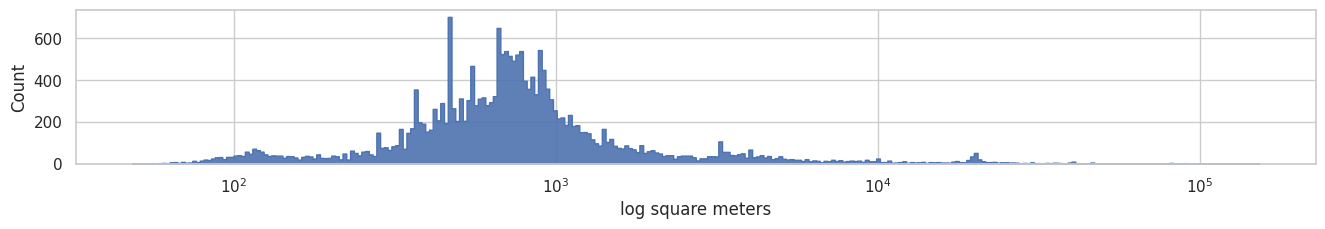

In [23]:
sns.set(rc={"figure.figsize":(16,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.sqm_lot, element='step', bins=300, alpha=0.9, log_scale=10)
plt.xlabel('log square meters')

In [24]:
kc.id.count()

np.int64(21613)

In [25]:
kc.loc[kc.sqm_living==kc.sqm_above,'sqm_above'].count()

np.int64(13126)

In [26]:
kc.loc[kc.sqm_above==kc.sqm_basement,'sqm_above'].count()

np.int64(551)

Text(0.5, 0, 'year built')

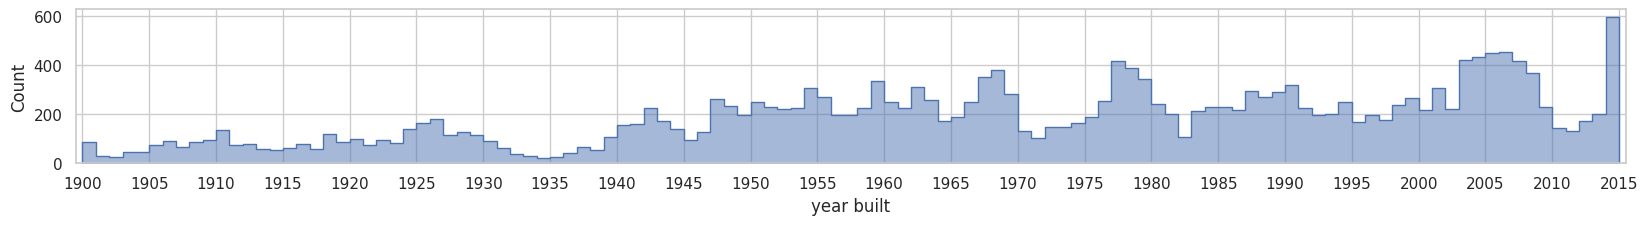

In [27]:
sns.set(rc={"figure.figsize":(20,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.yr_built, binrange=(1900,2015), binwidth=1, element='step', alpha=0.5)
plt.locator_params(axis='x', nbins=40)
plt.xlim(1899.5,2015.5)
plt.xlabel('year built')

Text(0.5, 0, 'year of renovation')

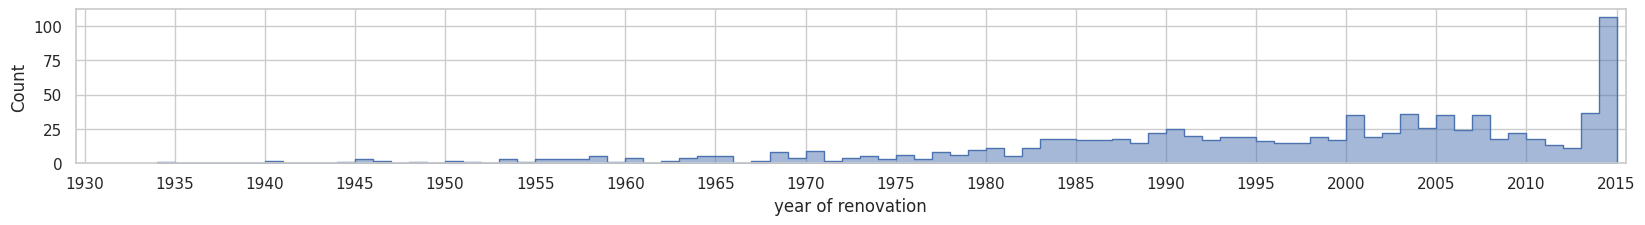

In [28]:
sns.set(rc={"figure.figsize":(20,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.yr_renovated, binrange=(1934,2015), binwidth=1, element='step', alpha=0.5)
plt.locator_params(axis='x', nbins=30)
plt.xlim(1929.5,2015.5)
plt.xlabel('year of renovation')

In [29]:
# px.scatter_map(kc, lat='lat', lon='long', size='sqm_living', size_max=10, zoom=9, template='plotly_dark',
#                color='price', map_style='carto-darkmatter', color_continuous_scale='plasma'
#                ).update_layout(margin=dict(l=0,r=0,b=0,t=0))

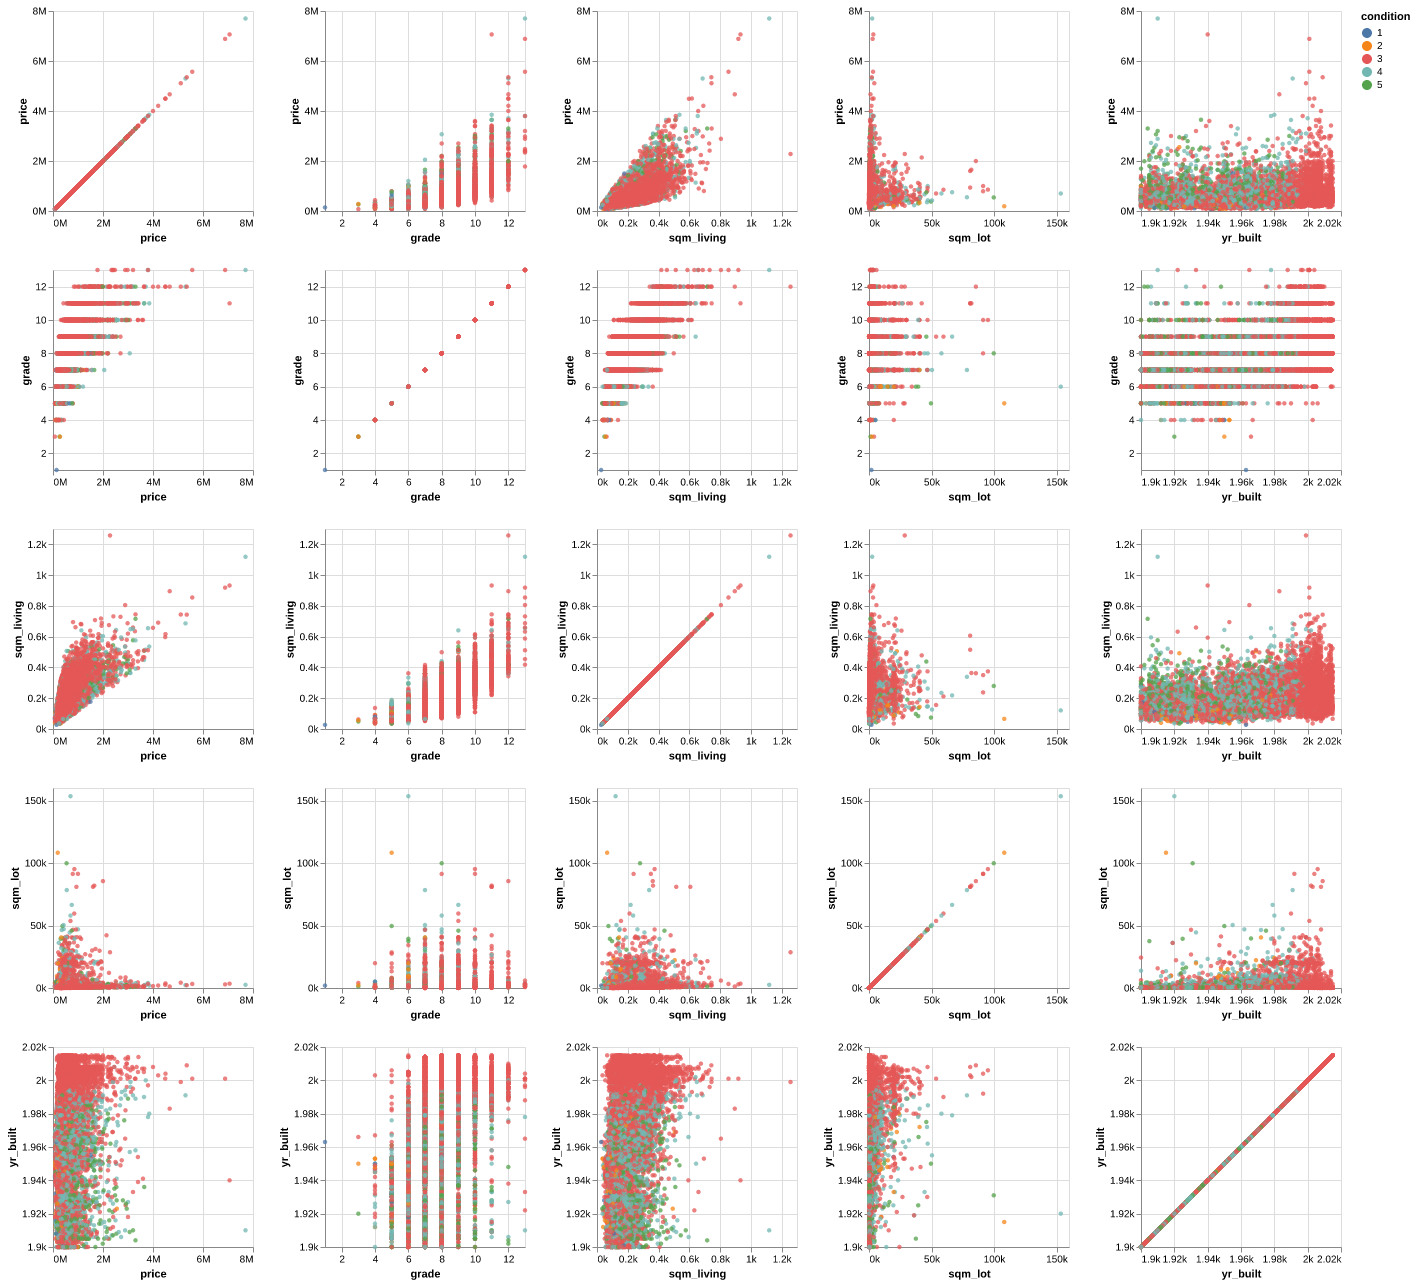

In [30]:
alt.Chart(kc).mark_circle(
    size=20, opacity=0.75, tooltip=True
).encode(
    alt.X(alt.repeat("column"), type='quantitative').scale(zero=False).axis(format='~s'),
    alt.Y(alt.repeat("row"), type='quantitative').scale(zero=False).axis(format='~s'),
    alt.Color('condition:N').scale(scheme='tableau10')
).properties(
    width=200,
    height=200
).repeat(
    row=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built'],
    column=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built']
).configure_facet(spacing=0
).configure_legend(symbolOpacity=1)

In [ ]:
###### Regression assumptions:
######
###### 1) Linearity - residual plot (against predicted values Y^)
######    - change reg. model, transform predictors
###### 2) Homoscedasticity -> risk of high p-values (type I error) - residual plot
######    - use Poisson regression (if counts) or weighted least squares regression
######    - transform the data
######    - use robust standard errors (of coefficients) - it transforms p-values
###### 3) Normality - kdeplot/histogram or QQplot, for residuals, Jarque-Bera
######    - add expl. variable
######    - transform data / change model
######    - remove outliers - Cook's distance ( threshold = 4 / (n - k - 1) )
###### 4) Independence (no autocorelation)
######    = if timeseries, check residuals vs time variable - transform the data
######    = Durbin-Watson (must be between 2 and 3)
###### 5) No colinearity - large condition number, Variance inflation factor (VIF) >5 
######                   -> inflated p-values, wide confidence intervals
######    - remove or combine variables (ex height and weight into bmi)
######    - principal component regression
######    - partial least squares regression

In [35]:
smf.ols('price ~ sqm_living', data = kc).fit(cov_type='HC1').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.493
Method:                 Least Squares   F-statistic:                     2469.
Date:                Fri, 19 Sep 2025   Prob (F-statistic):               0.00
Time:                        05:23:20   Log-Likelihood:            -3.0027e+05
No. Observations:               21613   AIC:                         6.005e+05
Df Residuals:                   21611   BIC:                         6.006e+05
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -4.358e+04   1.08e+04     -4.036      0.000   -6.47e+04   -2.24e+04
sqm_living  3020.6069     60.786     49.693      0.000    2901.469    3139.745
==============================================================================
Omnibus:                    14832.490   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           546444.713
Skew:                           2.824   Prob(JB):                         0.00
Kurtosis:                      26.977   Cond. No.                         523.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

<Axes: xlabel='sqm_living', ylabel='price'>

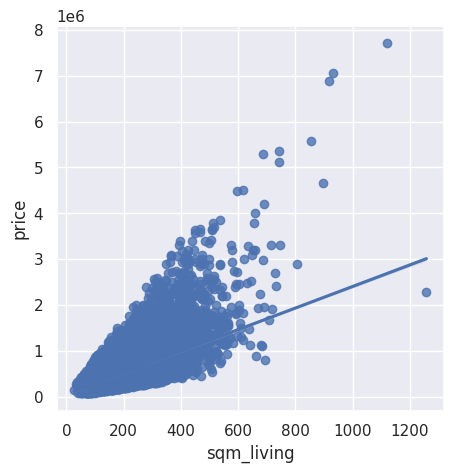

In [54]:
sns.regplot(kc, x='sqm_living', y='price', robust=True)

<Axes: xlabel='sqm_living', ylabel='price'>

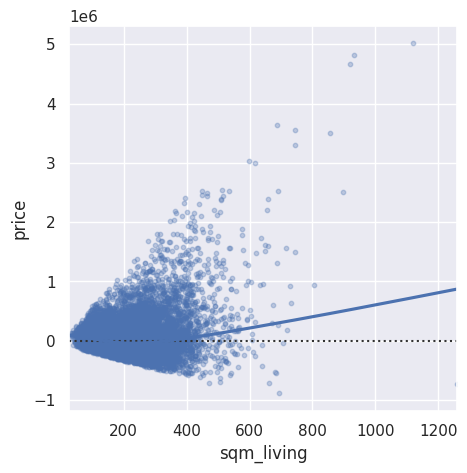

In [56]:
sns.residplot(kc, x='sqm_living', y='price', lowess=True, robust=True, scatter_kws={'s': 10, 'alpha':0.3})

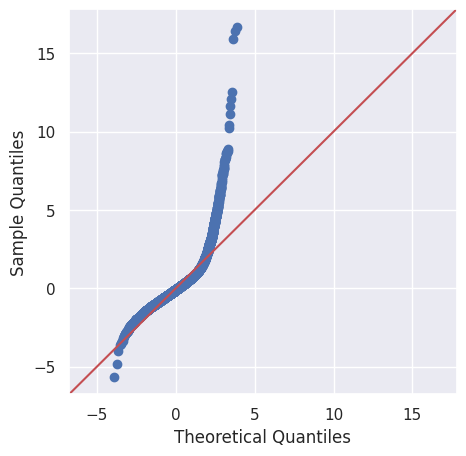

In [52]:
sns.set(rc={"figure.figsize":(5,5)})
sm.qqplot(data = smf.ols('price ~ sqm_living', data = kc).fit(cov_type='HC1').resid,
          line ='45', fit=True)
plt.show()

<Axes: ylabel='Count'>

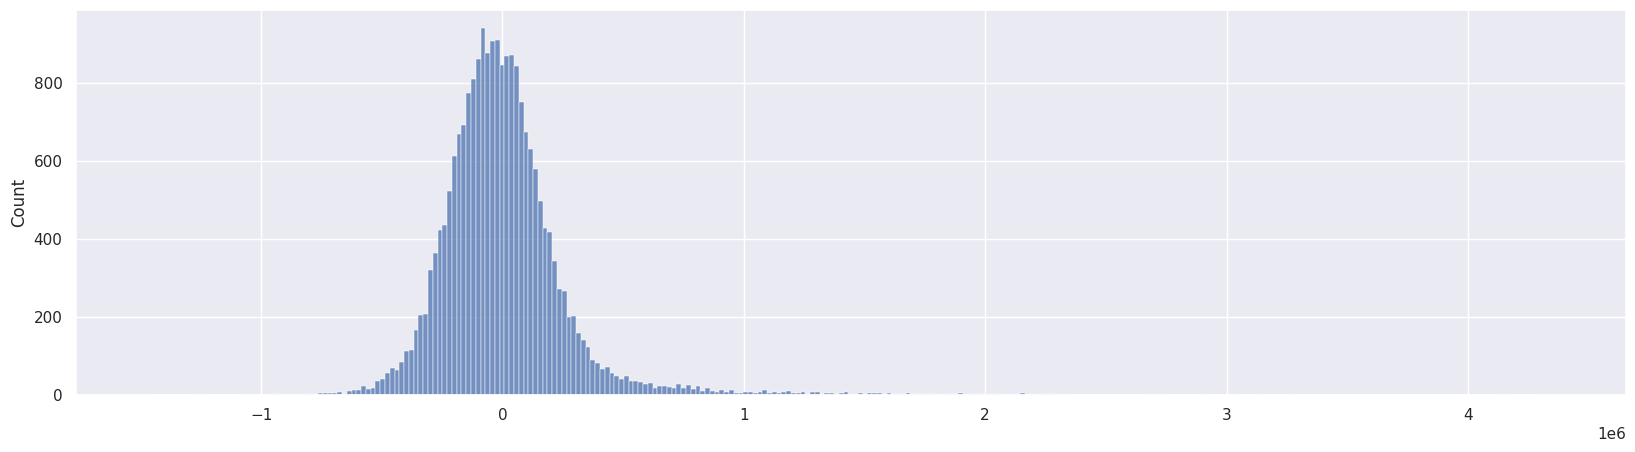

In [46]:
sns.set(rc={"figure.figsize":(20,5)})
sns.histplot(smf.ols('price ~ sqm_living', data = kc).fit(cov_type='HC1').resid)